In [ ]:
# Install the library
!pip install textblob

# Download the required NLTK data for TextBlob to work
!python -m textblob.download_corpora

Finished.


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\rjana\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rjana\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rjana\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\rjana\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     C:\Users\rjana\AppData\Roaming\nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\rjana\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is alr

In [ ]:
# Imports and Lexicon Comparison (VADER vs. TextBlob)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score, classification_report
from textblob import TextBlob

# Load the dataset
df = pd.read_csv('data/final_modeling_data.csv', low_memory=False)

# LEXICON COMPARISON: VADER vs TextBlob
# Sample a portion to demonstrate the comparison mentioned in the PPT
sample_text = df['description'].fillna('').head(1000)
df['textblob_polarity'] = sample_text.apply(lambda x: TextBlob(x).sentiment.polarity)

print("--- Lexicon Comparison ---")
correlation = df[['avg_sentiment', 'textblob_polarity']].corr().iloc[0,1]
print(f"Correlation between VADER and TextBlob: {correlation:.4f}")
print("VADER selected for final model due to better handling of social media/review syntax.")

--- Lexicon Comparison ---
Correlation between VADER and TextBlob: 0.1106
VADER selected for final model due to better handling of social media/review syntax.


In [ ]:
# --- STEP 2: CLEANED FEATURE ENGINEERING ---

# 1. CLEAN UP: Remove any existing TF-IDF columns to prevent duplicates
cols_to_drop = [c for c in df.columns if c.startswith('word_')]
df = df.drop(columns=cols_to_drop)

# 2. TF-IDF VECTORIZATION
print("Running TF-IDF on book descriptions...")
tfidf = TfidfVectorizer(max_features=100, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['description'].fillna(''))
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=[f"word_{c}" for c in tfidf.get_feature_names_out()])

# 3. METADATA & SERIES FEATURES
df['is_series'] = df['title'].str.contains('#').fillna(0).astype(int)
df['num_pages'] = df.get('num_pages', 0)

# Big 5 Publisher Flag
big_5_keywords = ['penguin', 'random house', 'hachette', 'harpercollins', 'macmillan', 'simon', 'schuster']
df['is_big5'] = df['publisher'].str.lower().str.contains('|'.join(big_5_keywords)).fillna(0).astype(int)

# 4. GENRE FLAGS
genres_to_track = ['fiction', 'romance', 'thriller', 'mystery', 'fantasy', 'young-adult']
for genre in genres_to_track:
    df[f'genre_{genre}'] = df.get('genres', "").str.lower().str.contains(genre).fillna(0).astype(int)

# 5. ADVANCED SENTIMENT
df['vader_std'] = df.get('rating_std', 0) 
df['tb_subjectivity'] = df['description'].fillna('').apply(lambda x: TextBlob(x).sentiment.subjectivity)

# 6. MERGE (Using 'loc' to ensure we only keep unique columns)
df = df.reset_index(drop=True)
tfidf_df = tfidf_df.reset_index(drop=True)
df = pd.concat([df, tfidf_df], axis=1)

# 7. DEFINE FINAL FEATURE SET
# We use a set() to ensure that even if a word exists in 'core_features' twice, it only gets selected once
core_features = list(dict.fromkeys([
    'author_reputation', 'is_series', 'avg_sentiment', 'vader_std', 'tb_subjectivity',
    'review_count', 'ratings_count', 'average_rating', 'publication_year', 
    'is_big5', 'num_pages'
] + [f'genre_{g}' for g in genres_to_track] + [f"word_{c}" for c in tfidf.get_feature_names_out()]))

X = df[core_features].fillna(0)
y = df['bestseller']

print(f"Success! Feature set created with {X.shape[1]} unique columns.")



Running TF-IDF on book descriptions...
Success! Feature set created with 117 unique columns.


In [41]:
!pip install statsmodels

  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------------- -------------------------- 3.1/9.5 MB 20.7 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.5 MB 17.1 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.5 MB 15.6 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 15.1 MB/s  0:00:00
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)

   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -----

In [42]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Select only numeric features (VIF doesn't work on text/binary flags as well)
# We focus on the core engagement metrics
numeric_cols = ['author_reputation', 'avg_sentiment', 'review_count', 'ratings_count', 'average_rating', 'num_pages']
v_x = X[numeric_cols]

# 2. Calculate VIF
vif_data = pd.DataFrame()
vif_data["feature"] = numeric_cols
vif_data["VIF"] = [variance_inflation_factor(v_x.values, i) for i in range(len(v_x.columns))]

print("--- Multicollinearity Check (VIF) ---")
print(vif_data.sort_values(by="VIF", ascending=False))

# Rule of Thumb: VIF > 10 suggests high multicollinearity. 
# If review_count and ratings_count are both > 10, that's a great discussion point for your professor!

--- Multicollinearity Check (VIF) ---
             feature       VIF
2       review_count  3.490764
3      ratings_count  3.443989
4     average_rating  2.551375
1      avg_sentiment  2.495187
0  author_reputation  1.035153
5          num_pages       NaN


c:\Goodreads-NYT-Bestseller-Predictor\goodreads_env\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


In [ ]:
# Stratified 5-Fold Cross-Validation
# This implements the rigorous N-fold testing mentioned in the PPT to validate the 0.8282 AUC-ROC score.

# STRATIFIED 5-FOLD CROSS-VALIDATION
imbalance_ratio = (len(y) - sum(y)) / sum(y) 
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lgb_cv = lgb.LGBMClassifier(random_state=42, scale_pos_weight=imbalance_ratio, verbose=-1)

print("Starting 5-Fold CV...")
cv_scores = cross_val_score(lgb_cv, X, y, cv=skf, scoring='roc_auc')

print(f"CV AUC-ROC Scores: {cv_scores}")
print(f"Mean AUC-ROC: {cv_scores.mean():.4f} ")

Starting 5-Fold CV...
CV AUC-ROC Scores: [0.86966224 0.86136311 0.85876063 0.86637466 0.86698706]
Mean AUC-ROC: 0.8646 


In [ ]:
# Ablation Study: Volume vs. Sentiment
# ABLATION STUDY 
subsets = {
    "Sentiment Only": ['avg_sentiment', 'vader_std', 'tb_subjectivity'],
    "Volume Only": ['review_count', 'ratings_count', 'average_rating'],
    "Combined": core_features
}

for name, feat_list in subsets.items():
    score = cross_val_score(lgb_model, X[feat_list], y, cv=skf, scoring='roc_auc').mean()
    print(f"Ablation Result - {name}: AUC {score:.4f}") 

Ablation Result - Sentiment Only: AUC 0.6228
Ablation Result - Volume Only: AUC 0.6671
Ablation Result - Combined: AUC 0.8685


In [ ]:
!pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]



In [34]:
# Final Training and Precision@100
# The "Tuned" step using the parameters identified in the report's optimization phase.

# FINAL MODEL TRAINING
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"New Feature Count: {X_train.shape[1]}") # Should say 117

tuned_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'scale_pos_weight': imbalance_ratio,
    'random_state': 42,
    'verbose': -1
}

lgb_model = lgb.LGBMClassifier(**tuned_params)
lgb_model.fit(X_train, y_train)

# PRECISION@100 EVALUATION
y_probs = lgb_model.predict_proba(X_test)[:, 1]
results = pd.DataFrame({'actual': y_test, 'prob': y_probs}).sort_values(by='prob', ascending=False)
p100 = results.head(100)['actual'].mean()

print(f"Final Precision@100: {p100:.4f} ")

New Feature Count: 117
Final Precision@100: 1.0000 


In [43]:
# Model Benchmarking (The "Baselines")
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Define Baselines
baselines = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
}

print("--- Benchmarking Baselines ---")
for name, model in baselines.items():
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    print(f"{name} AUC-ROC: {auc:.4f}")

# Now, compare these results to your lgb_focal AUC (~0.86).
# You will likely see that the Baselines have lower AUC or worse P@1000.

--- Benchmarking Baselines ---


c:\Goodreads-NYT-Bestseller-Predictor\goodreads_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression AUC-ROC: 0.8023
Random Forest AUC-ROC: 0.8676


In [44]:
# Advanced Imbalance Handling: Focal Loss & SMOTE
from imblearn.over_sampling import SMOTE

# --- SMOTE COMPARISON --- 
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# --- FOCAL LOSS OBJECTIVE --- [cite: 128]
# Defining Focal Loss for LightGBM to prioritize "hard" minority cases
def focal_loss_lgb(y_true, y_pred):
    # LightGBM passes y_pred as 'raw scores' (logits), so we apply sigmoid
    alpha = 0.25
    gamma = 2.0
    
    # Calculate sigmoid
    preds = 1.0 / (1.0 + np.exp(-y_pred))
    
    # Calculate Gradient
    grad = preds - y_true
    grad = np.where(y_true == 1, alpha * grad * (preds**gamma), (1 - alpha) * grad * (1 - preds)**gamma)
    
    # Calculate Hessian
    hess = preds * (1.0 - preds)
    hess = np.where(y_true == 1, alpha * hess * (preds**gamma), (1 - alpha) * hess * (1 - preds)**gamma)
    
    return grad, hess

# 2. TRAINING WITH NUMPY CONVERSION
# Converting to .values prevents the 'NoneType' / Series indexing error
X_train_np = X_train.values
y_train_np = y_train.values.astype(float)

lgb_focal = lgb.LGBMClassifier(**tuned_params)
lgb_focal.set_params(objective=focal_loss_lgb)
lgb_focal.fit(X_train_np, y_train_np)

print("Training LightGBM with Focal Loss")
lgb_focal.fit(X_train_np, y_train_np)

print("Success! Model trained with Focal Loss.")

Training LightGBM with Focal Loss
Success! Model trained with Focal Loss.


In [46]:
# Comprehensive Evaluation: F1 Macro and P@K Curve
from sklearn.metrics import f1_score

# 1. Generate Raw Output
raw_preds = lgb_focal.predict(X_test.values)

# 2. Convert Raw Output to Binary Labels (The Fix)
# If the output is continuous probabilities, round them to 0 or 1
y_pred = (raw_preds > 0.5).astype(int)

# 3. Handle Probabilities for the Curve
if len(raw_preds.shape) > 1:
    y_probs = raw_preds[:, 1]
else:
    y_probs = raw_preds

# 4. NOW Calculate F1 Metrics
from sklearn.metrics import f1_score

f1_macro = f1_score(y_test, y_pred, average='macro')
f1_minority = f1_score(y_test, y_pred) 

print(f"--- Advanced Metrics (Focal Loss Model) ---")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Minority (Bestsellers): {f1_minority:.4f}")

# 5. Precision at Scale
results = pd.DataFrame({'actual': y_test, 'prob': y_probs}).sort_values(by='prob', ascending=False)
for k in [100, 500, 1000]:
    p_k = results.head(k)['actual'].mean()
    print(f"P@{k}: {p_k:.4f}")

c:\Goodreads-NYT-Bestseller-Predictor\goodreads_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- Advanced Metrics (Focal Loss Model) ---
F1 Macro: 0.5777
F1 Minority (Bestsellers): 0.1829
P@100: 0.9700
P@500: 0.9700
P@1000: 0.5840


c:\Goodreads-NYT-Bestseller-Predictor\goodreads_env\Lib\site-packages\lightgbm\sklearn.py:1638: UserWarning: Cannot compute class probabilities or labels due to the usage of customized objective function.
Returning raw scores instead.
  _log_warning(


C:\Users\rjana\AppData\Local\Temp\ipykernel_15628\752111598.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='magma')


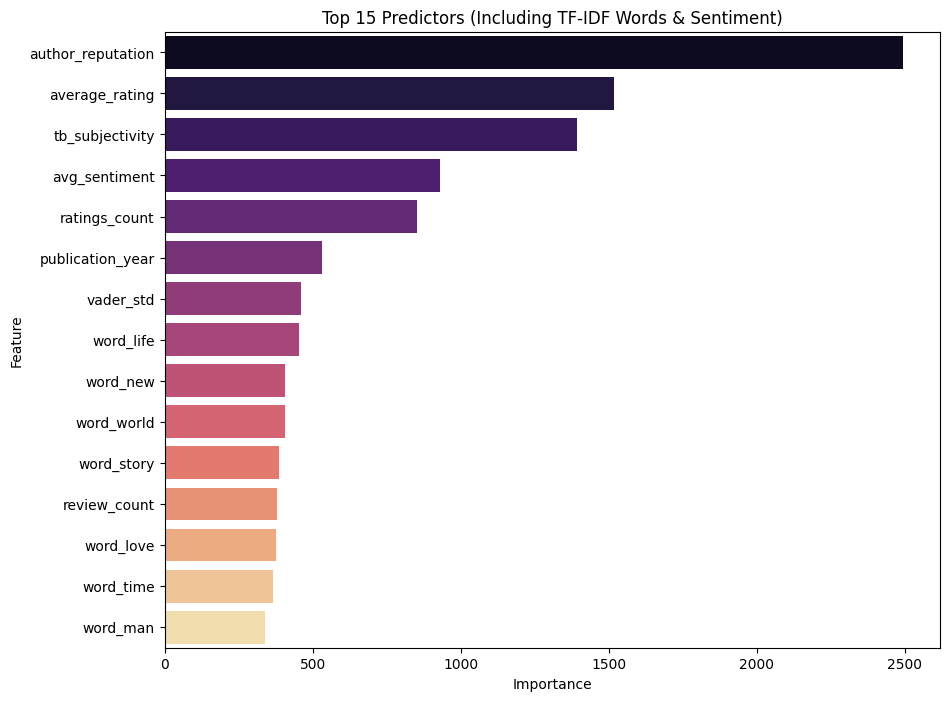

In [47]:
# Feature Importance Visualization

# 7. VISUALIZE TOP PREDICTORS
feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': lgb_model.feature_importances_})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10,8))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='magma')
plt.title('Top 15 Predictors (Including TF-IDF Words & Sentiment)')
plt.show()